# Assignment 1 - Constructive heuristics for the Set Covering Problem (SCP)

**Course:** Heuristic Optimization &nbsp;|&nbsp; **Deadline:** 02/10/26

What this notebook does, in the order of the assignment:

| Step | Content |
|---|---|
| 0 | Theory: SCP, constructive vs. improvement heuristics, static vs. **dynamic** construction |
| 1 | Reading the instances |
| 2 | Solution state with **incremental** updates (add / remove a set) |
| 3 | **a)** three dynamic constructive heuristics CH1, CH2, CH3 |
| 4 | **b)** redundancy elimination RE |
| 5 | Sanity check on the toy example from the slides |
| 6 | **c) + d)** experiments: CH1-CH3 with and without RE, fraction of instances helped by RE |
| 7 | Extension: **neighbourhood-based** heuristic (iterative improvement) starting from the constructive solutions |
| 8 | Comparison of all our solutions with the best solution (`best_solution.txt`, used only here) |
| 9 | Conclusions |

Style rules used throughout: only plain functions (no classes), a solution state is a small dictionary of arrays,
and every function that changes the state does so **incrementally** (nothing is recomputed from scratch).

## 0. Theory

### The Set Covering Problem
Given

* elements $A=\{a_1,\dots,a_m\}$,
* a family of subsets $F=\{A_1,\dots,A_n\}$, $A_i\subseteq A$, whose union is $A$,
* a cost $w(A_i)>0$ for every subset,

find $C^*\subseteq F$ that **covers** every element and has **minimum total cost**

$$C^* \in \arg\min_{C\in \text{Covers}(A,F)} \; w(C),\qquad w(C)=\sum_{A_i\in C} w(A_i).$$

Integer program ($x_i=1$ iff subset $i$ is selected, $b_{ij}=1$ iff subset $i$ contains element $j$):

$$\min \sum_{i=1}^n w_i x_i \quad\text{s.t.}\quad \sum_{i=1}^n b_{ij}\,x_i \ge 1\;\;(j=1..m),\qquad x_i\in\{0,1\}.$$

The problem is NP-hard, so for large instances we use **heuristics**: fast, simple, no optimality guarantee.

### Constructive vs. improvement heuristics
* A **constructive heuristic** builds a solution one piece at a time, starting from the empty (partial) solution.
  It must decide *what to add next* (selection rule) and evaluate **partial** solutions. Interrupted early it gives no usable solution.
* An **improvement heuristic** (local search) starts from a *complete* solution and only compares complete solutions.
* A **compound heuristic** = constructive phase followed by improvement phase. This is what we do in Section 7.

### Greedy construction: static vs. dynamic
A greedy rule takes, in every step, the decision that looks best according to a scoring function.

* **Static** greedy: the scores are computed **once** before the construction (e.g. sort sets by cost or by cost / size and go through the list).
  Cheap, but blind: after some sets are chosen, the remaining sets overlap with what is already covered and their static score is *wrong*.
* **Dynamic** greedy: the scores are **recomputed after every step**, so they always describe the *current partial solution*.
  For the SCP the important quantity is the number of **still uncovered** elements a set would cover, `new_cov[j]`.

**All constructive heuristics in this notebook are dynamic:** the candidate list (sets with `new_cov > 0`),
the set of uncovered elements and the scores change after every added set, and we maintain them incrementally (Section 2).

Connection to the lecture (A* / best-first): the evaluation of a partial solution $q$ is $\text{eval}(q)=c(q)+h(q)$,
where $c(q)$ is the cost paid so far and $h(q)$ estimates the cost of finishing. The greedy ratio
$\dfrac{w_j}{\text{new\_cov}_j}$ is a cheap estimate of "price per still-uncovered element" - a heuristic $h$ that is **not** a lower bound
(so this is not A*, and optimality is not guaranteed).

## 1. Imports and data

In [25]:
import random
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

DATA = Path("SCP-Instances 2")   # folder with the OR-Library SCP files
SEED = 1                         # the same seed is used for every instance / method

### Instance file format (OR-Library)
```
m n                      number of elements (rows) and sets (columns)
c_1 ... c_n              cost of every set
for every element i:     k_i, then the k_i sets (1-based) that cover element i
```
We keep both directions of the incidence relation, because the incremental updates need both:

* `rows_of_col[j]` - elements covered by set `j`
* `cols_of_row[e]` - sets that cover element `e`

In [2]:
def invert(lists, size):
    # 'lists[i]' holds items in range(size); return, for every item, the list of i that contain it
    out = [[] for _ in range(size)]
    for i, items in enumerate(lists):
        for x in items:
            out[x].append(i)
    return [np.array(o, dtype=np.int64) for o in out]


def build_instance(name, cost, rows_of_col, m):
    # an instance is a plain dictionary
    return {"name": name, "m": m, "n": len(cost), "cost": np.array(cost, dtype=float),
            "rows_of_col": [np.array(r, dtype=np.int64) for r in rows_of_col],
            "cols_of_row": invert(rows_of_col, m)}


def read_instance(path):
    tok = np.array(Path(path).read_text().split(), dtype=np.int64)
    m, n = tok[0], tok[1]
    cost = tok[2:2 + n]
    pos = 2 + n
    cols_of_row = []
    for _ in range(m):
        k = tok[pos]
        cols_of_row.append(tok[pos + 1:pos + 1 + k] - 1)      # to 0-based
        pos += 1 + k
    assert pos == len(tok), "unexpected data at the end of the file"
    return build_instance(Path(path).stem, cost, invert(cols_of_row, n), m)

In [3]:
def natural_key(p):
    # scp42 < scp51 < scpa1 < scpa2 ...
    return p.stem.rstrip("0123456789"), int(p.stem[len(p.stem.rstrip("0123456789")):])

files = sorted(DATA.glob("scp*.txt"), key=natural_key)
instances = [read_instance(f) for f in files]

pd.DataFrame([{"instance": i["name"], "elements m": i["m"], "sets n": i["n"],
               "avg cost": i["cost"].mean()} for i in instances]).set_index("instance").T

instance,scp42,scp43,scp44,scp45,scp46,scp47,scp48,scp49,scp51,scp52,scp53,scp54,scp55,scp56,scp57,...,scpb1,scpb2,scpb3,scpb4,scpb5,scpc1,scpc2,scpc3,scpc4,scpc5,scpd1,scpd2,scpd3,scpd4,scpd5
elements m,200.00,200.000,200.000,200.00,200.000,200.000,200.000,200.000,200.0000,200.000,200.0000,200.000,200.0000,200.0000,200.0000,...,300.00,300.000,300.000000,300.000,300.000000,400.00000,400.00000,400.00000,400.0000,400.00000,400.0000,400.0000,400.0000,400.0000,400.0000
sets n,1000.00,1000.000,1000.000,1000.00,1000.000,1000.000,1000.000,1000.000,2000.0000,2000.000,2000.0000,2000.000,2000.0000,2000.0000,2000.0000,...,3000.00,3000.000,3000.000000,3000.000,3000.000000,4000.00000,4000.00000,4000.00000,4000.0000,4000.00000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000
avg cost,49.83,50.176,50.264,49.79,51.277,48.933,52.261,51.932,50.6395,51.557,49.2755,49.488,50.7675,51.5235,50.6225,...,50.63,50.652,50.988667,49.563,50.466667,50.88775,49.81325,51.09775,50.2625,50.73425,50.8935,49.9495,51.0505,50.2535,50.5205


## 2. Solution state with incremental updates

A (partial) solution is stored together with everything the heuristics need to make their next decision:

| field | meaning | why |
|---|---|---|
| `in_sol[j]` | set `j` is selected | the solution itself |
| `cnt[e]` | how many selected sets cover element `e` | `cnt[e]==0` uncovered; a set is *redundant* iff all its elements have `cnt>=2` |
| `new_cov[j]` | number of **uncovered** elements set `j` still contains | the **dynamic** score; `new_cov[j]==0` means `j` is not a candidate (adding it would be redundant) |
| `uncovered`, `pos` | list of uncovered elements with O(1) insert / delete | to pick an uncovered element quickly |
| `cost` | total cost of the selected sets | the evaluation function value |
| `log` | list of performed `add`/`remove` operations | lets the local search **undo** a tried move without copying the state |

**Incremental update rules** (this is the core of the whole notebook):

* **add set `j`:** for every element `e` of `j` with `cnt[e]==0` (it becomes covered): remove `e` from `uncovered` and decrease `new_cov[s]` by 1 for **every set `s` that contains `e`**.
  Then `cnt[e]+=1` for all elements of `j`, and `cost += w_j`.
* **remove set `j`:** `cnt[e]-=1` for all elements of `j`; every element whose count drops to 0 becomes uncovered again,
  so add it to `uncovered` and increase `new_cov[s]` by 1 for every set `s` containing it. `cost -= w_j`.

`remove` is the exact inverse of `add`. Only the elements of `j` and the sets touching them are visited - the cost of one update is tiny compared with recomputing all scores.

In [4]:
def new_state(inst):
    # empty partial solution: nothing covered, every set could still cover all of its elements
    return {"in_sol": np.zeros(inst["n"], dtype=bool),
            "cnt": np.zeros(inst["m"], dtype=np.int64),
            "new_cov": np.array([len(r) for r in inst["rows_of_col"]], dtype=np.int64),
            "uncovered": list(range(inst["m"])),
            "pos": list(range(inst["m"])),          # pos[e] = index of e inside 'uncovered'
            "cost": 0.0,
            "log": []}


def mark_covered(st, e):
    # O(1) removal from the uncovered list: move the last element into e's slot
    i, last = st["pos"][e], st["uncovered"][-1]
    st["uncovered"][i] = last
    st["pos"][last] = i
    st["uncovered"].pop()


def mark_uncovered(st, e):
    st["pos"][e] = len(st["uncovered"])
    st["uncovered"].append(e)


def add_set(inst, st, j, log=True):
    rows = inst["rows_of_col"][j]
    for e in rows[st["cnt"][rows] == 0]:                 # elements that become covered now
        mark_covered(st, e)
        st["new_cov"][inst["cols_of_row"][e]] -= 1       # every set containing e has one uncovered element less
    st["cnt"][rows] += 1
    st["in_sol"][j] = True
    st["cost"] += inst["cost"][j]
    if log:
        st["log"].append(("add", j))


def remove_set(inst, st, j, log=True):
    rows = inst["rows_of_col"][j]
    st["cnt"][rows] -= 1
    for e in rows[st["cnt"][rows] == 0]:                 # elements that become uncovered now
        mark_uncovered(st, e)
        st["new_cov"][inst["cols_of_row"][e]] += 1
    st["in_sol"][j] = False
    st["cost"] -= inst["cost"][j]
    if log:
        st["log"].append(("remove", j))


def undo_to(inst, st, mark):
    # revert all operations after position 'mark' of the log (newest first)
    while len(st["log"]) > mark:
        op, j = st["log"].pop()
        if op == "add":
            remove_set(inst, st, j, log=False)
        else:
            add_set(inst, st, j, log=False)


def is_redundant(inst, st, j):
    # selected set j is redundant iff every element it covers is also covered by another selected set
    return bool(np.all(st["cnt"][inst["rows_of_col"][j]] >= 2))


def selected_sets(st):
    return np.flatnonzero(st["in_sol"])

### Independent check of the bookkeeping
Incremental code is easy to get subtly wrong, so we add a function that rebuilds everything **from scratch** from the list of selected sets
and compares it with the incrementally maintained values. It is called after every run in the experiments.

In [5]:
def check_state(inst, st, complete=True, minimal=False):
    # recompute counts, uncovered elements, new_cov and cost from scratch and compare
    sel = selected_sets(st)
    cnt = np.zeros(inst["m"], dtype=np.int64)
    for j in sel:
        cnt[inst["rows_of_col"][j]] += 1
    assert (cnt == st["cnt"]).all(), "cnt out of sync"
    assert set(np.flatnonzero(cnt == 0)) == set(st["uncovered"]), "uncovered list out of sync"
    new_cov = np.array([np.sum(cnt[r] == 0) for r in inst["rows_of_col"]])
    assert (new_cov == st["new_cov"]).all(), "new_cov out of sync"
    assert abs(inst["cost"][sel].sum() - st["cost"]) < 1e-6, "cost out of sync"
    if complete:
        assert (cnt > 0).all(), "not a cover"
    if minimal:
        assert not any(is_redundant(inst, st, j) for j in sel), "a redundant set is left"
    return st["cost"]

## 3. a) Three dynamic constructive heuristics

All three follow the same skeleton:

```
partial solution = empty
while some element is uncovered:
    choose the next set j  (rule differs)      <- the only difference between CH1, CH2, CH3
    add_set(j)                                  <- incremental update of the state
```

**No redundant set is ever added.** In CH1 and CH2 the chosen set always contains the selected uncovered element, so `new_cov >= 1`.
In CH3 only sets with `new_cov > 0` are candidates. In other words the *candidate list is dynamic*: sets whose elements are all covered already drop out automatically (their `new_cov` reaches 0).

| | which uncovered element? | which set? | information used |
|---|---|---|---|
| **CH1** | random | random set covering it | none (the example from the assignment) |
| **CH2** | random | the set covering it with the best ratio $w_j/\text{new\_cov}_j$ | cost + current coverage |
| **CH3** | implicit (all elements considered) | the best ratio $w_j/\text{new\_cov}_j$ over **all** candidate sets | cost + current coverage, global view |

CH3 is the classical **greedy heuristic of Chvatal (1979)**; it is known to have an approximation guarantee of $H(d)\le 1+\ln d$ ($d$ = size of the largest set).
CH2 is a cheaper, "element-driven" compromise: restricting the choice to sets that cover a given element makes the step cheap and keeps randomness,
but it may pick a set that is much worse than the globally best one.

Ties in the ratio are broken **randomly**, so the same seed gives the same solution but different seeds give different ones.

In [6]:
def random_uncovered(st, rng):
    return st["uncovered"][rng.randrange(len(st["uncovered"]))]


def pick_min(scores, candidates, rng):
    # index (from 'candidates') with the smallest score; ties are broken at random
    s = scores[candidates]
    best = candidates[s == s.min()]
    return int(best[rng.randrange(len(best))])


def ch1(inst, rng):
    # random uncovered element -> random set that covers it
    st = new_state(inst)
    while st["uncovered"]:
        e = random_uncovered(st, rng)
        cols = inst["cols_of_row"][e]
        add_set(inst, st, int(cols[rng.randrange(len(cols))]))
    return st


def ch2(inst, rng):
    # random uncovered element -> the set covering it with the lowest cost / new_cov
    st = new_state(inst)
    while st["uncovered"]:
        e = random_uncovered(st, rng)
        cols = inst["cols_of_row"][e]                         # all of them have new_cov >= 1
        ratio = inst["cost"][cols] / st["new_cov"][cols]      # dynamic score, always up to date
        best = cols[ratio == ratio.min()]
        add_set(inst, st, int(best[rng.randrange(len(best))]))
    return st


def greedy_complete(inst, st, rng, banned=-1):
    # complete ANY partial solution with the dynamic greedy rule of CH3.
    # 'banned' = a set that must not be chosen (used later by the neighbourhood move)
    while st["uncovered"]:
        cand = np.flatnonzero(st["new_cov"] > 0)              # dynamic candidate list
        if banned >= 0 and len(cand) > 1:
            cand = cand[cand != banned]
        ratio = inst["cost"] / np.maximum(st["new_cov"], 1)
        add_set(inst, st, pick_min(ratio, cand, rng))
    return st


def ch3(inst, rng):
    # Chvatal greedy = complete the empty solution with the dynamic greedy rule
    return greedy_complete(inst, new_state(inst), rng)


CONSTRUCTIVE = {"CH1": ch1, "CH2": ch2, "CH3": ch3}

## 4. b) Redundancy elimination (RE)

**Why it is needed.** The construction only guarantees that a set was *useful when it was added*.
Later sets may cover all its elements, so in the complete cover it can be redundant: removing it keeps the cover feasible and **strictly decreases the cost** (all costs are positive).

**Procedure.**
1. Order the selected sets by **decreasing cost** - the most expensive redundant set is the most profitable one to drop (ties: random).
2. For each set in this order: if all its elements have `cnt >= 2`, remove it (incremental `remove_set`).

**One pass is enough.** Removing a set can only *lower* the counts `cnt`, so a set that was not redundant when examined can never become redundant later.
After the pass no redundant set is left (the cover is *minimal*, not necessarily minimum). Note that the order matters for the result, which is why we use the cost order.

RE is in fact already a tiny local search with the neighbourhood "drop one set" - we generalise this idea in Section 7.

In [7]:
def redundancy_elimination(inst, st, rng):
    sel = list(selected_sets(st))
    rng.shuffle(sel)                                  # random order first ...
    sel.sort(key=lambda j: -inst["cost"][j])          # ... then by decreasing cost (sort is stable -> random ties)
    removed = 0
    for j in sel:
        if is_redundant(inst, st, j):
            remove_set(inst, st, j)
            removed += 1
    return removed

## 5. Sanity check on the toy example from the slides

$A=\{a,\dots,g\}$, $F=\{A_1=\{a,b,d,g\},\,A_2=\{a,b,c\},\,A_3=\{e,f,g\},\,A_4=\{f,g\},\,A_5=\{d,e\},\,A_6=\{c,d\}\}$, costs $6,3,5,4,5,4$.
The slides show the (non-optimal) cover $\{A_1,A_2,A_4,A_5\}$ of cost 18. With 6 sets we can find the true optimum by brute force and watch the dynamic greedy scores change step by step.

In [8]:
letters = "abcdefg"
toy_sets = ["abdg", "abc", "efg", "fg", "de", "cd"]
toy = build_instance("toy", [6, 3, 5, 4, 5, 4],
                     [[letters.index(x) for x in s] for s in toy_sets], m=7)

# brute force over all 2^6 selections
best = min((sum(toy["cost"][list(c)]) , c) for r in range(1, 7)
           for c in itertools.combinations(range(6), r)
           if set().union(*[set(toy_sets[j]) for j in c]) == set(letters))
print("optimum:", best[0], "with sets", [f"A{j+1}" for j in best[1]])

# CH3 step by step: the ratio w/new_cov changes after every step (dynamic!)
st = new_state(toy)
step = 1
while st["uncovered"]:
    ratio = np.where(st["new_cov"] > 0, toy["cost"] / np.maximum(st["new_cov"], 1), np.inf)
    print(f"step {step}: ratios = {np.round(ratio, 2)}  uncovered = {sorted(letters[e] for e in st['uncovered'])}")
    j = int(np.argmin(ratio))
    print(f"        pick A{j+1}")
    add_set(toy, st, j)
    step += 1
print("cost before RE:", st["cost"], "-> removed", redundancy_elimination(toy, st, random.Random(0)),
      "redundant set(s), cost after RE:", st["cost"], "| selected:", [f"A{j+1}" for j in selected_sets(st)])
check_state(toy, st, minimal=True);

optimum: 12.0 with sets ['A2', 'A3', 'A6']
step 1: ratios = [1.5  1.   1.67 2.   2.5  2.  ]  uncovered = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
        pick A2
step 2: ratios = [3.    inf 1.67 2.   2.5  4.  ]  uncovered = ['d', 'e', 'f', 'g']
        pick A3
step 3: ratios = [ 6. inf inf inf  5.  4.]  uncovered = ['d']
        pick A6
cost before RE: 12.0 -> removed 0 redundant set(s), cost after RE: 12.0 | selected: ['A2', 'A3', 'A6']


## 6. c) + d) Experiments: CH1-CH3 with and without RE

**Protocol** (as required):
* every constructive heuristic is applied **once** to every instance;
* every run starts from `random.Random(SEED)` - the same seed for all instances and methods;
* the *same* constructed cover is evaluated **without** RE and **with** RE (RE is applied to exactly that cover), so the comparison is fair;
* after each run `check_state` re-verifies feasibility, cost and (after RE) minimality.

**Measures.** In this section we only look at **our own** solutions (the reference solution file is used only in Section 8).
For an instance $i$ with construction cost $f_i$ and cost after RE $f_i^{RE}$:

$$\text{RE gain}_i = 100\cdot\frac{f_i-f_i^{RE}}{f_i}\;[\%],\qquad
\text{fraction helped by RE}=\frac{|\{i: f_i^{RE}<f_i\}|}{|I|}.$$

We also count on how many instances each method gives the lowest cost among CH1-CH3 (with RE).

In [9]:
def run_construction(inst, method, seed):
    # construct once, then post-process the same cover with RE
    rng = random.Random(seed)
    t0 = time.perf_counter()
    st = CONSTRUCTIVE[method](inst, rng)
    cost = check_state(inst, st)
    t1 = time.perf_counter()
    removed = redundancy_elimination(inst, st, rng)
    cost_re = check_state(inst, st, minimal=True)
    t2 = time.perf_counter()
    return {"cost": cost, "cost_re": cost_re, "sets_removed": removed,
            "sec_ch": t1 - t0, "sec_re": t2 - t1}, st


def gain(before, after):
    # percentage by which the cost decreased
    return 100.0 * (before - after) / before


rows = []
for inst in instances:
    for method in CONSTRUCTIVE:
        res, _ = run_construction(inst, method, SEED)
        rows.append({"instance": inst["name"], "method": method, **res})

res_df = pd.DataFrame(rows)
res_df["re_gain"] = gain(res_df.cost, res_df.cost_re)
res_df["helped_by_re"] = res_df.cost_re < res_df.cost
res_df["group"] = res_df.instance.str.extract(r"scp(\d|[a-d])")[0].str.upper()
res_df.head(6)

,instance,method,cost,cost_re,sets_removed,sec_ch,sec_re,re_gain,helped_by_re,group
0,scp42,CH1,4544.0,2990.0,23,0.003450,0.003223,34.198944,True,4
1,scp42,CH2,580.0,556.0,1,0.003472,0.003180,4.137931,True,4
2,scp42,CH3,590.0,547.0,11,0.004456,0.003099,7.288136,True,4
3,scp43,CH1,3721.0,2706.0,19,0.003319,0.003189,27.277614,True,4
4,scp43,CH2,644.0,620.0,6,0.003443,0.003073,3.726708,True,4
5,scp43,CH3,598.0,546.0,14,0.004089,0.003166,8.695652,True,4


### d) Main result: how much does RE help, and for how many instances?

In [10]:
lowest = res_df.cost_re == res_df.groupby("instance").cost_re.transform("min")   # ties count for every tied method
g = res_df.groupby("method")
summary = pd.DataFrame({
    "avg cost (no RE)":   g.cost.mean(),
    "avg cost (with RE)": g.cost_re.mean(),
    "avg RE gain %": g.re_gain.mean(),
    "fraction helped by RE": g.helped_by_re.mean(),
    "# helped": g.helped_by_re.sum().astype(int),
    "avg sets removed": g.sets_removed.mean(),
    "# lowest cost (with RE)": lowest.groupby(res_df.method).sum().astype(int),
    "avg time CH [s]": g.sec_ch.mean(),
})
summary.round(3)

,avg cost (no RE),avg cost (with RE),avg RE gain %,fraction helped by RE,# helped,avg sets removed,# lowest cost (with RE),avg time CH [s]
method,,,,,,,,
CH1,4112.452,3162.095,23.059,1.000,42,16.571,0,0.007
CH2,291.119,280.571,3.713,0.952,40,3.976,2,0.007
CH3,274.476,257.357,5.782,1.000,42,7.762,41,0.008


### Per-instance results
Each cell: cost of the construction / cost after RE.

In [11]:
def fmt(r):
    return f"{r.cost:.0f} / {r.cost_re:.0f}"

per_inst = res_df.assign(txt=res_df.apply(fmt, axis=1)).pivot(index="instance", columns="method", values="txt")
per_inst.loc[[i["name"] for i in instances]]

method,CH1,CH2,CH3
instance,,,
scp42,4544 / 2990,580 / 556,590 / 547
scp43,3721 / 2706,644 / 620,598 / 546
scp44,3806 / 2852,642 / 606,548 / 507
scp45,4027 / 3382,584 / 561,577 / 519
scp46,4381 / 3575,746 / 737,606 / 588
scp47,4373 / 3337,498 / 485,476 / 447
scp48,4627 / 3633,584 / 566,546 / 537
scp49,4783 / 3515,768 / 743,750 / 672
scp51,4187 / 3421,307 / 294,282 / 273


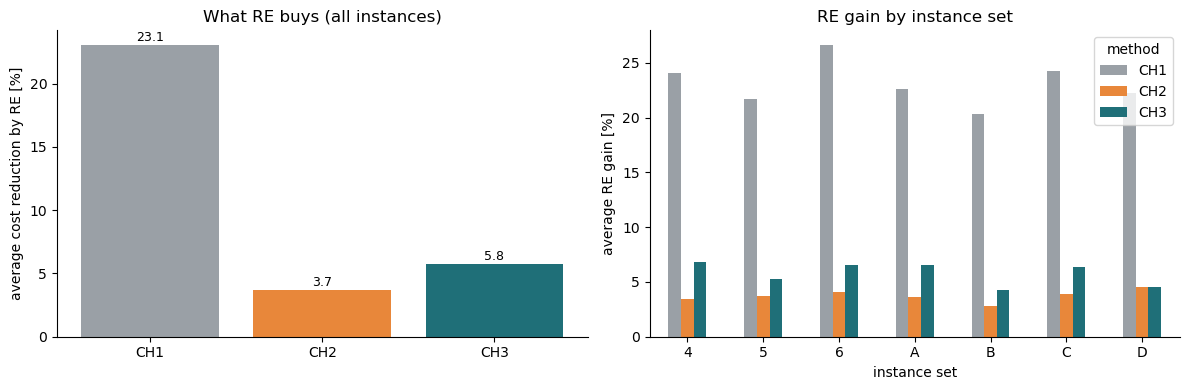

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

bars = axs[0].bar(summary.index, summary["avg RE gain %"], color=["#9aa0a6", "#e8873a", "#1f6f78"])
axs[0].set_ylabel("average cost reduction by RE [%]"); axs[0].set_title("What RE buys (all instances)")
for r in bars:
    axs[0].text(r.get_x() + r.get_width()/2, r.get_height() + 0.3, f"{r.get_height():.1f}", ha="center", fontsize=9)

order = ["4", "5", "6", "A", "B", "C", "D"]
gg = res_df.groupby(["group", "method"])["re_gain"].mean().unstack().reindex(order)
gg.plot.bar(ax=axs[1], color=["#9aa0a6", "#e8873a", "#1f6f78"], rot=0)
axs[1].set_xlabel("instance set"); axs[1].set_ylabel("average RE gain [%]"); axs[1].set_title("RE gain by instance set")
for ax in axs: ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Robustness check (extra)
The assignment asks for one run per instance, but CH1 and CH2 are randomised, so a single seed can be lucky or unlucky.
Repeating the whole experiment with 10 different seeds shows how much the RE statistics move.

In [13]:
rob = []
for seed in range(1, 11):
    for method in CONSTRUCTIVE:
        gains, helped = [], []
        for inst in instances:
            r, _ = run_construction(inst, method, seed)
            gains.append(gain(r["cost"], r["cost_re"])); helped.append(r["cost_re"] < r["cost"])
        rob.append({"method": method, "seed": seed, "RE gain %": np.mean(gains), "helped": np.mean(helped)})
rob = pd.DataFrame(rob).groupby("method").agg(["mean", "std"]).drop(columns="seed")
rob.round(3)

RE gain %        helped       
            mean    std   mean    std
method                               
CH1       23.017  0.863  1.000  0.000
CH2        3.687  0.437  0.976  0.019
CH3        6.077  0.309  0.995  0.010

## 7. Extension: neighbourhood-based heuristic (iterative improvement)

### Theory
A **neighbourhood** $N(S)$ of a solution $S$ is the set of solutions reachable from $S$ by one small change (a *move*).
**Iterative improvement** (local search) repeats *"move to a better neighbour"* until none exists; the result is a **local optimum** with respect to $N$.
The constructive solution is the **starting point**; compound heuristic = construction + local search.

Design decisions:

1. **Neighbourhood - "drop and repair".** For a cover $S$ and a selected set $j\in S$:
   1. remove $j$ (some elements become uncovered),
   2. **repair** with the dynamic greedy rule (`greedy_complete`, with $j$ forbidden so we really leave $S$),
   3. run redundancy elimination (the repaired cover may contain redundant sets).

   $N(S)=\{\,\text{RE}(\text{repair}(S\setminus\{j\})) \;:\; j\in S\,\}$ - it has $|S|$ neighbours and **every neighbour is a feasible cover**,
   so we never have to deal with infeasible solutions. This is a small "destroy & rebuild" neighbourhood: bigger than a plain swap, but still cheap.
   (RE alone is the special case where we only drop sets and do not repair.)
2. **Evaluation by delta / undo.** A neighbour is *applied* to the state with the incremental `add_set` / `remove_set`, its cost is read off `st["cost"]`,
   and if it is not accepted the logged operations are **undone** - the state is never copied or recomputed.
3. **Pivot rule.**
   * *first improvement* - take the first improving neighbour found (neighbours scanned in random order): cheap steps, more of them;
   * *best improvement* - scan the whole neighbourhood, take the best one: expensive steps, steeper descent.
4. **Stopping:** when no neighbour is strictly better (local optimum). The cost strictly decreases and is bounded below, so the search terminates.

In [14]:
def apply_drop_and_repair(inst, st, j, rng):
    # one move: drop j, repair greedily (without j), remove redundant sets
    remove_set(inst, st, j)
    greedy_complete(inst, st, rng, banned=j)
    redundancy_elimination(inst, st, rng)


def replay(inst, st, ops):
    for op, j in ops:
        add_set(inst, st, j) if op == "add" else remove_set(inst, st, j)


def local_search(inst, st, rng, pivot="first"):
    # iterative improvement in the drop-and-repair neighbourhood; modifies 'st' in place
    iterations = 0
    while True:
        st["log"].clear()
        current = st["cost"]
        best_cost, best_ops = current, None
        neighbours = list(selected_sets(st))
        rng.shuffle(neighbours)                               # random scan order
        for j in neighbours:
            mark = len(st["log"])
            apply_drop_and_repair(inst, st, j, rng)
            if st["cost"] < best_cost - 1e-9:                 # strictly better neighbour
                if pivot == "first":
                    best_ops = []                             # keep the move: the state already is the neighbour
                    break
                best_cost, best_ops = st["cost"], list(st["log"][mark:])   # remember the moves of the best one
            undo_to(inst, st, mark)                           # not (yet) accepted -> undo incrementally
        if best_ops is None:                                  # no improving neighbour: local optimum
            return iterations
        if pivot == "best":
            replay(inst, st, best_ops)                        # re-apply the best neighbour found
        iterations += 1

### Test on one real instance
Before running everything: check that the local search returns a valid, minimal cover that is never worse than its start,
and that the incremental bookkeeping is still consistent after thousands of `add`/`remove`/`undo` operations (`check_state` recomputes it from scratch).

In [15]:
inst = instances[0]                     # scp42
for pivot in ["first", "best"]:
    rng = random.Random(SEED)
    st = ch1(inst, rng)
    redundancy_elimination(inst, st, rng)
    before = st["cost"]
    t0 = time.perf_counter()
    it = local_search(inst, st, rng, pivot)
    check_state(inst, st, minimal=True)
    print(f"{inst['name']} CH1+RE -> local search ({pivot:5s}): {before:.0f} -> {st['cost']:.0f} "
          f"in {it} improving moves, {time.perf_counter() - t0:.2f}s")

scp42 CH1+RE -> local search (first): 2990 -> 551 in 52 improving moves, 0.07s


scp42 CH1+RE -> local search (best ): 2990 -> 528 in 33 improving moves, 0.51s


### Experiment: CH1-CH3 + RE + local search
Same protocol as before (one run per instance and method, same seed); the local search starts from the cover **after RE**.
We report the cost after each stage, the gain of the local search

$$\text{LS gain}_i = 100\cdot\frac{f_i^{RE}-f_i^{LS}}{f_i^{RE}}\;[\%]$$

and on how many instances the local search finds an improvement.

In [16]:
def run_compound(inst, method, seed, pivot):
    rng = random.Random(seed)
    st = CONSTRUCTIVE[method](inst, rng)
    cost = st["cost"]
    redundancy_elimination(inst, st, rng)
    cost_re = check_state(inst, st, minimal=True)
    t0 = time.perf_counter()
    iters = local_search(inst, st, rng, pivot)
    cost_ls = check_state(inst, st, minimal=True)
    return {"cost": cost, "cost_re": cost_re, "cost_ls": cost_ls, "moves": iters, "sec_ls": time.perf_counter() - t0}


rows = []
for inst in instances:
    for method in CONSTRUCTIVE:
        for pivot in ["first", "best"]:
            rows.append({"instance": inst["name"], "method": method, "pivot": pivot,
                         **run_compound(inst, method, SEED, pivot)})
ls_df = pd.DataFrame(rows)
ls_df["ls_gain"] = gain(ls_df.cost_re, ls_df.cost_ls)
ls_df["helped_by_ls"] = ls_df.cost_ls < ls_df.cost_re
ls_df["group"] = ls_df.instance.str.extract(r"scp(\d|[a-d])")[0].str.upper()

In [17]:
g = ls_df.groupby(["method", "pivot"])
ls_summary = pd.DataFrame({
    "avg cost after RE":  g.cost_re.mean(),
    "avg cost after LS":  g.cost_ls.mean(),
    "avg LS gain %": g.ls_gain.mean(),
    "fraction helped by LS": g.helped_by_ls.mean(),
    "avg # moves": g.moves.mean(),
    "avg time LS [s]": g.sec_ls.mean(),
})
ls_summary.round(3)

avg cost after RE  avg cost after LS  avg LS gain %  fraction helped by LS  avg # moves  avg time LS [s]
method pivot                                                                                                          
CH1    best            3162.095            251.357         92.129                  1.000       32.429            0.542
       first           3162.095            252.619         92.090                  1.000       54.000            0.083
CH2    best             280.571            251.619          9.260                  1.000        5.857            0.111
       first            280.571            252.714          9.223                  1.000        8.048            0.048
CH3    best             257.357            249.167          3.332                  0.857        3.238            0.078
       first            257.357            249.929          3.038                  0.857        3.619            0.036

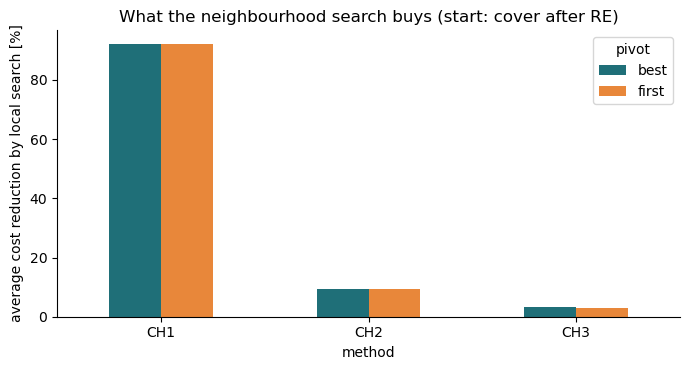

In [18]:
ax = ls_summary["avg LS gain %"].unstack().plot.bar(figsize=(7, 3.8), color=["#1f6f78", "#e8873a"], rot=0)
ax.set_ylabel("average cost reduction by local search [%]"); ax.set_title("What the neighbourhood search buys (start: cover after RE)")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

## 8. Comparison with the best solution

Only now do we use `SCP-Instances 2/best_solution.txt`. It contains the **best solution ever found** for every benchmark instance (for these instances
the optimum or the best value reported in the literature). It is **not** used anywhere in the construction or the search - it is only the yardstick.

File format: one line per instance, `<set>.<number> <cost>`, e.g. `4.2 512`, `5.10 265`, `A.1 253`;
we translate the label into the instance name (`4.2` -> `scp42`, `A.1` -> `scpa1`).
The file also contains scp41, scp410 and scp510, which are not in the instance folder, so they are ignored.

**Percentage deviation** of a heuristic cost $f_i$ from the best solution cost $b_i$:

$$\text{dev}_i = 100\cdot\frac{f_i-b_i}{b_i}\;[\%],\qquad \overline{\text{dev}}=\frac1{|I|}\sum_{i\in I}\text{dev}_i .$$

Since $b_i$ is the best solution ever found, $\text{dev}_i\ge 0$ must hold for every correct solution - a useful extra sanity check of our code.

In [19]:
def read_best(path):
    # 'label cost' per line;  '4.2' -> 'scp42',  '5.10' -> 'scp510',  'A.1' -> 'scpa1'
    best = {}
    for line in Path(path).read_text().splitlines():
        if line.strip():
            label, value = line.split()
            group, number = label.split(".")
            best["scp" + group.lower() + number] = int(value)
    return best


BEST = read_best(DATA / "best_solution.txt")
assert all(i["name"] in BEST for i in instances)
print(len(BEST), "best solutions read,", len(instances), "of them have an instance file")


def dev(cost, best):
    return 100.0 * (cost - best) / best


# one row per instance, method and stage
stage_rows = []
for r in ls_df.itertuples():
    b = BEST[r.instance]
    stage_rows += [
        {"instance": r.instance, "group": r.group, "method": r.method, "stage": "construction",      "cost": r.cost,    "best": b},
        {"instance": r.instance, "group": r.group, "method": r.method, "stage": "+ RE",               "cost": r.cost_re, "best": b},
        {"instance": r.instance, "group": r.group, "method": r.method, "stage": f"+ LS ({r.pivot})",  "cost": r.cost_ls, "best": b},
    ]
final = pd.DataFrame(stage_rows).drop_duplicates(["instance", "method", "stage"])
final["dev"] = dev(final.cost, final.best)
assert (final.dev >= -1e-9).all(), "a heuristic solution is better than the best solution ever - check data/code"

45 best solutions read, 42 of them have an instance file


### Average percentage deviation from the best solution, per method and stage

In [20]:
stage_order = ["construction", "+ RE", "+ LS (first)", "+ LS (best)"]
avg_dev = final.groupby(["method", "stage"]).dev.mean().unstack()[stage_order]
avg_dev.round(2)

stage,construction,+ RE,+ LS (first),+ LS (best)
method,,,,
CH1,2297.07,1755.70,4.50,3.75
CH2,19.45,14.99,4.22,4.17
CH3,13.05,6.49,3.21,2.89


In [21]:
# how many instances are solved to the best cost, and the worst case
hit = final.assign(hit=final.dev < 1e-9).groupby(["method", "stage"]).hit.sum().unstack()[stage_order].astype(int)
worst = final.groupby(["method", "stage"]).dev.max().unstack()[stage_order]
print("number of instances (out of %d) where the best solution cost is reached:" % len(instances)); display(hit)
print("largest deviation [%]:"); display(worst.round(1))

number of instances (out of 42) where the best solution cost is reached:


stage,construction,+ RE,+ LS (first),+ LS (best)
method,,,,
CH1,0,0,0,2
CH2,0,0,2,0
CH3,0,0,3,2


largest deviation [%]:


stage,construction,+ RE,+ LS (first),+ LS (best)
method,,,,
CH1,5487.1,4664.5,11.8,10.5
CH2,33.2,31.6,10.1,13.3
CH3,19.3,15.0,12.4,12.4


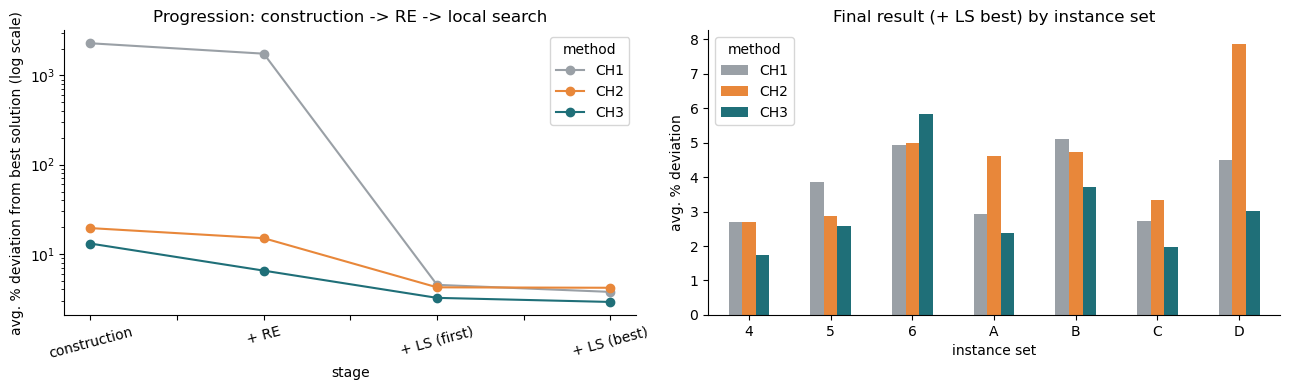

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

avg_dev.T.plot(marker="o", ax=axs[0], logy=True, color=["#9aa0a6", "#e8873a", "#1f6f78"])
axs[0].set_ylabel("avg. % deviation from best solution (log scale)"); axs[0].set_title("Progression: construction -> RE -> local search")
axs[0].tick_params(axis="x", rotation=15)

order = ["4", "5", "6", "A", "B", "C", "D"]
gb = final[final.stage == "+ LS (best)"].groupby(["group", "method"]).dev.mean().unstack().reindex(order)
gb.plot.bar(ax=axs[1], color=["#9aa0a6", "#e8873a", "#1f6f78"], rot=0)
axs[1].set_xlabel("instance set"); axs[1].set_ylabel("avg. % deviation"); axs[1].set_title("Final result (+ LS best) by instance set")
for ax in axs: ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Per-instance comparison
Costs of the final stage of each method (construction + RE + local search with best improvement) next to the best solution, with the deviation in brackets.

In [23]:
f = final[final.stage == "+ LS (best)"]
tab = f.assign(txt=f.apply(lambda r: f"{r.cost:.0f} ({r.dev:.1f}%)", axis=1)).pivot(index="instance", columns="method", values="txt")
tab.insert(0, "best solution", pd.Series(BEST))
tab.loc[[i["name"] for i in instances]]

method,best solution,CH1,CH2,CH3
instance,,,,
scp42,512,528 (3.1%),526 (2.7%),536 (4.7%)
scp43,516,537 (4.1%),520 (0.8%),520 (0.8%)
scp44,494,505 (2.2%),518 (4.9%),504 (2.0%)
scp45,512,525 (2.5%),523 (2.1%),518 (1.2%)
scp46,560,568 (1.4%),564 (0.7%),565 (0.9%)
scp47,430,437 (1.6%),450 (4.7%),432 (0.5%)
scp48,492,497 (1.0%),495 (0.6%),493 (0.2%)
scp49,641,677 (5.6%),674 (5.1%),664 (3.6%)
scp51,253,255 (0.8%),264 (4.3%),258 (2.0%)


## 9. Conclusions

*(statements refer to the run above with `SEED = 1`; the tables hold the exact values)*

* **Information in the selection rule matters most.** CH1 ignores costs and coverage and is orders of magnitude worse than CH2 / CH3;
  adding the dynamic ratio $w_j/\text{new\_cov}_j$ (CH2) removes almost all of that gap; using it globally (CH3) is best (Section 8, "construction" column).
* **RE never hurts and helps on (almost) every instance.** The sets chosen early are often made redundant by later choices. The gain is largest for the careless CH1 and for the greedy CH3,
  which tends to pick big sets early; it is smallest for CH2 (Section 6).
* **A cover after RE is only minimal, not minimum.** The neighbourhood search (drop one set, repair greedily, RE) escapes many of these local traps and improves
  nearly every solution again; the price is running time (best improvement is the slowest pivot rule, first improvement is cheaper but ends slightly worse).
* **The local search largely washes out the quality of the starting point** - even the poor CH1 cover ends within a few percent of the best solution,
  because the greedy repair inside the move keeps replacing costly sets by cost-effective ones. The good starting point of CH3 still gives the best final result
  with the fewest moves, i.e. a better construction saves search effort.
* **No heuristic solution beat the best solution ever** (checked by an assertion); the remaining gap of a few percent is what a pure constructive + simple local search method leaves on the table,
  and is the motivation for stronger methods (e.g. metaheuristics) in the next part of the course.
* **Dynamic bookkeeping makes all this affordable:** each add / remove / undo touches only the elements of one set and the sets containing them,
  and `check_state` confirms after every run that the incremental values agree with a from-scratch recomputation.